In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv", header=None)

## Functions for plotting

In [4]:
def plot_line(w, b, color='k', style='-', label=None):
    x_vals = np.linspace(-2, 2, 100)
    if w[1] != 0:
        y_vals = -(w[0]/w[1])*x_vals - b/w[1]
        plt.plot(x_vals, y_vals, color=color, linestyle=style, label=label)


In [6]:
def plot_perceptron_training(X, y, initial_w, initial_b, lines):
    plt.figure(figsize=(7,7))

    # scatter points
    plt.scatter(X['x1'], X['x2'], c=y, cmap='viridis', edgecolor='k')

    # 1. initial line
    plot_line(initial_w, initial_b, color='red', style='-', label='initial')

    # 2. intermediate lines
    for w, b in lines[:-1]:
        plot_line(w, b, color='green', style='--')

    # 3. final line
    w_last, b_last = lines[-1]
    plot_line(w_last, b_last, color='black', style='-', label='final')

    plt.ylim(-0.25, 1.25)
    plt.xlim(-0.25, 1.25)
    plt.legend()
    plt.title("Perceptron Decision Boundary Updates")
    plt.show()


In [7]:
def plot_error_curve(error_list):
    plt.figure(figsize=(8,5))
    plt.plot(range(len(error_list)), error_list, marker='o')
    plt.xlabel("Number of epochs")
    plt.ylabel("Error")
    plt.title("Error Plot")
    plt.grid(True)
    plt.show()

# Part 1

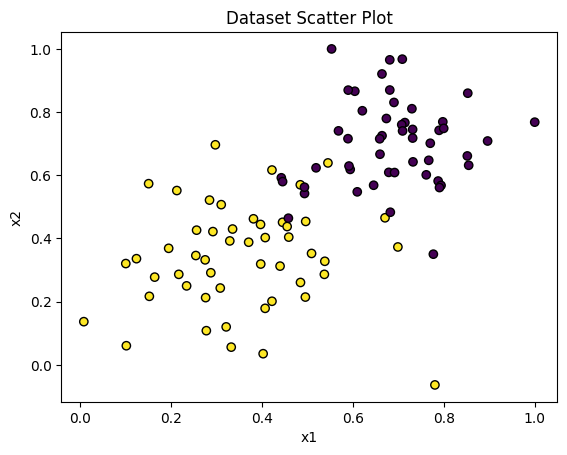

In [3]:
df.columns = ['x1', 'x2', 'label']
X = df.drop('label', axis=1)
y = df['label']
df.head().style.set_table_styles(
    [{'selector': 'th', 'props': [('font-weight', 'bold'),
                                  ('background-color', '#f0f0f0')]}]
).set_properties(**{
    'border': '1px solid #ccc',
    'padding': '6px'
})
plt.scatter(X['x1'], X['x2'],c=y, cmap='viridis', edgecolor='k')
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dataset Scatter Plot")
plt.show()

In [5]:
def perceptron_heuristic(X, y, learning_rate, max_epochs):
    w = np.random.randn(2)  
    b = np.random.randn()
    initial_w = w.copy()
    initial_b = b
    lines = []
    error_list = []
    n = len(X)
    for epoch in range(max_epochs):
        for i in range(n):
            x1 = X['x1'][i]
            x2 = X['x2'][i]
            classification = w[0]*x1 + w[1]*x2 + b
            label_hat = 1 if classification >= 0 else 0
            if (label_hat != y[i]):
                if label_hat == 0:
                    b = b + learning_rate
                    w[0] = w[0] + learning_rate * x1
                    w[1] = w[1] + learning_rate * x2
                else:
                    b = b - learning_rate
                    w[0] = w[0] - learning_rate * x1
                    w[1] = w[1] - learning_rate * x2
                lines.append((w.copy(), b))
                errors = 0
                
        for i in range(n):
            x1 = X['x1'][i]
            x2 = X['x2'][i]
            classification = w[0]*x1 + w[1]*x2 + b
            label_hat = 1 if classification >= 0 else 0
            if label_hat != y[i]:
                errors += 1

        error_list.append(errors / n)
    return initial_w, initial_b, lines, error_list      

## Learning rate evaluation

Given that the dataset only has 100 data points, I will chose a epoch value of 3, this is because it will provide a clean plot that will be easy to interpret and still show meaningful movement of the decision boundary.

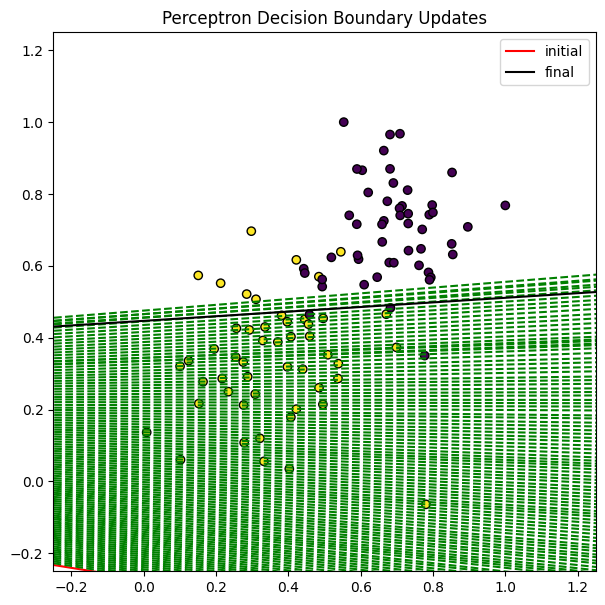

In [62]:
initial_w, initial_b, lines, error_list = perceptron_heuristic(X, y, learning_rate=0.01, max_epochs=3)
plot_perceptron_training(X, y, initial_w, initial_b, lines)

In the graph above, there is some good general seperation between the two different classes. We can also see the very small difference between the green lines, this is because of the small learning rate ensuring that we don't over jump the seperation boundary. The downside of a smaller learning rate is that it may need more epochs to show progress.

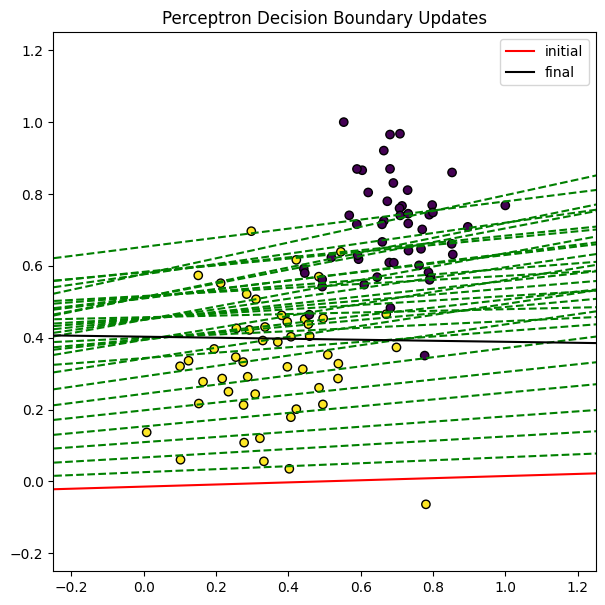

In [68]:
initial_w, initial_b, lines, error_list = perceptron_heuristic(X, y, learning_rate=0.1, max_epochs=3)
plot_perceptron_training(X, y, initial_w, initial_b, lines)

The graph shows poor performance compared to the previous one when the learning rate is 0.1. This is because the training converges faster, resulting in an overshoot of the solution boundary. Comparing it to the previous graph, it is also noticeable that there are fewer green lines.

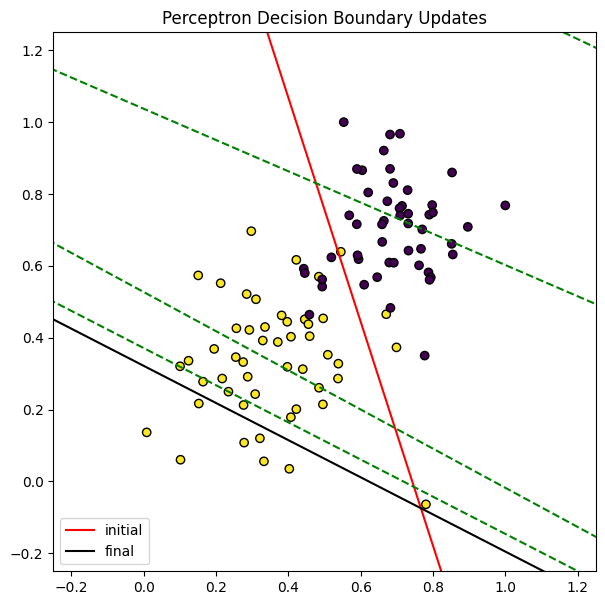

In [70]:
initial_w, initial_b, lines, error_list = perceptron_heuristic(X, y, learning_rate=1.0, max_epochs=3)
plot_perceptron_training(X, y, initial_w, initial_b, lines)

This graph shows the worst performance overall as there is an alarming amount of misclassification. This happens because the learning rate is too huge, resulting in a massive overstep of correction for the decision boundary. This method is less stable for 3 epochs

## Error Analysis

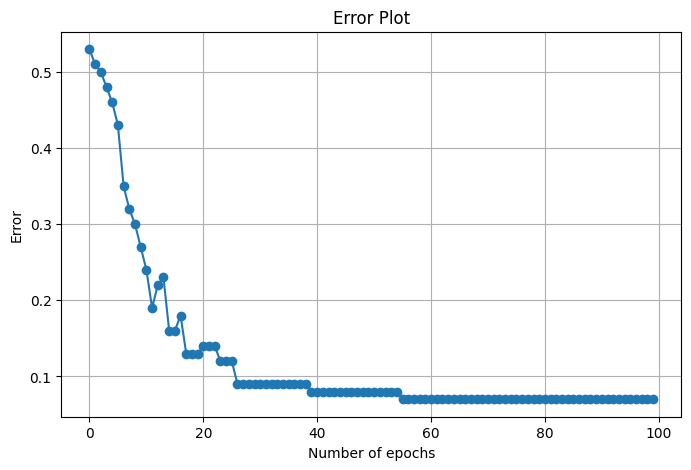

In [76]:
initial_w, initial_b, lines, error_list = perceptron_heuristic(X, y, learning_rate=0.01, max_epochs=100)
plot_error_curve(error_list)

We can see that when the learning rate is 0.01, that it takes a lot of epochs to have minimal error, this happens because a low learning rate converges slowly, but is more stable and controlled compared to a faster/higher training rate. 

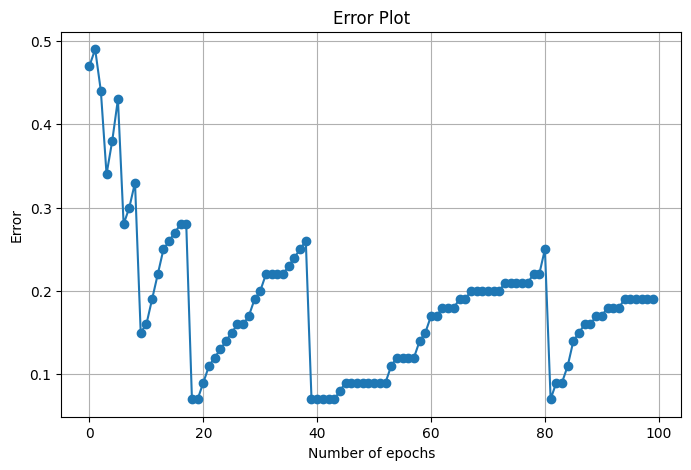

In [79]:
initial_w, initial_b, lines, error_list = perceptron_heuristic(X, y, learning_rate=0.1, max_epochs=100)
plot_error_curve(error_list)

We can see that on the y-axis there is less variance in the error rate compared to the last one. The issue with this learning rate of 0.1, it is clear that there is a periodic jump up in the error rate, signifying how unstable this training method is. We can also notice that the final 100th epoch has a higher error rate compared to the previous graph.

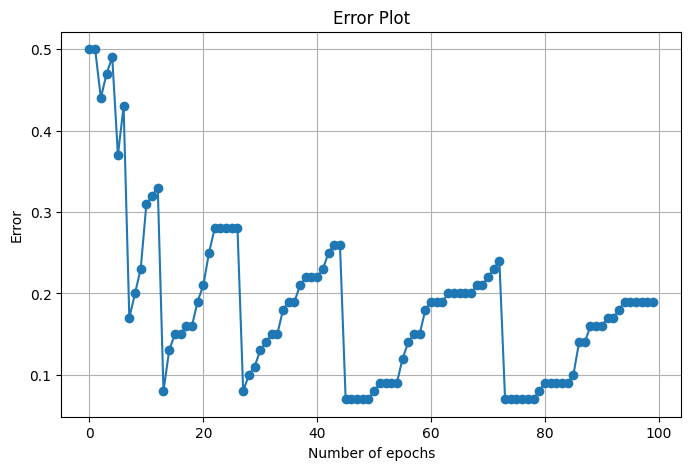

In [82]:
initial_w, initial_b, lines, error_list = perceptron_heuristic(X, y, learning_rate=1.0, max_epochs=100)
plot_error_curve(error_list)

In this graph, we can see that it is similar to the previous graph where ther learning rate is 0.1, except that in this graph there tends to be more periodic spikes in the error rate. We can also see that on the 100th epoch, this graph produced the highest error rate compared to the others. 

# Conclusion

After some testing and multiple runs, I noticed that for this small dataset of 100 values, a low learning rate is the preferred approach, as it yields stable, controlled convergence to the solution boundary. It is important to note that this could be computationally expensive, since it requires more epochs than a higher learning rate, which requires fewer epochs. One key takeaway from this is the randomness. Since each perceptron starts with random weights and a random b-term, the accuracy of the solution boundary may vary drastically. This analysis does overall capture the general trend and performance for each learning rate. 

# Part 2

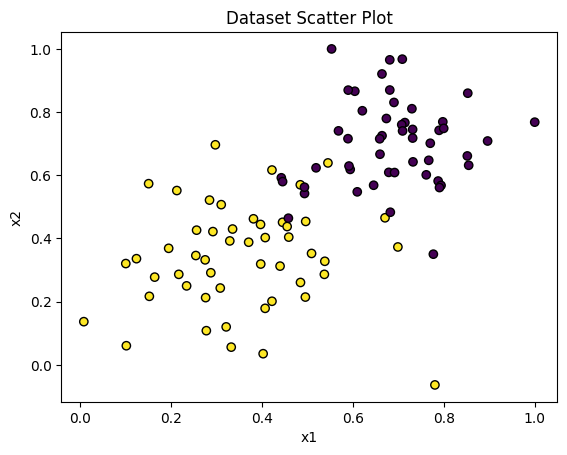

In [83]:
plt.scatter(X['x1'], X['x2'], c=y, cmap='viridis', edgecolor='k')
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dataset Scatter Plot")
plt.show()

In [84]:
def perceptron_gradient(X, y, learning_rate, max_epochs=20):
    w = np.random.randn(2)
    b = np.random.randn()
    initial_w = w.copy()
    initial_b = b
    lines = []
    n = len(X)
    error_list = []
    for epoch in range(max_epochs):
        for i in range(n):
            z = w[0]*X['x1'][i] + w[1]*X['x2'][i] + b
            y_hat = 1 / (1 + np.exp(-z))
            error = y[i] - y_hat
            b = b + learning_rate*error
            w[0] = w[0] + learning_rate * error * X['x1'][i]
            w[1] = w[1] + learning_rate * error * X['x2'][i]
            lines.append((w.copy(), b)) 

        loss = 0
        for i in range(n):
            z = w[0]*X['x1'][i] + w[1]*X['x2'][i] + b
            y_hat = 1 / (1 + np.exp(-z))
            y_hat = np.clip(y_hat, 1e-10, 1 - 1e-10)

            loss += -(y[i] * np.log(y_hat) + (1 - y[i]) * np.log(1 - y_hat))
        loss /= n
        error_list.append(loss)
    return initial_w, initial_b, lines, error_list

## Learning rate evaluation


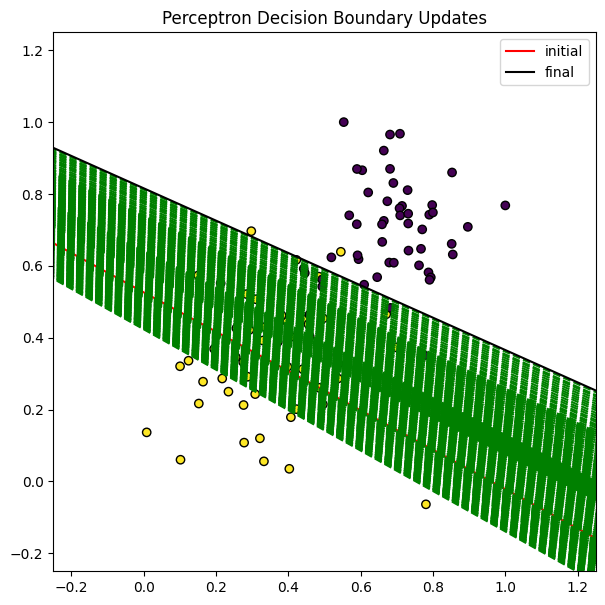

In [91]:
initial_w, initial_b, lines, error_list = perceptron_gradient(X, y, learning_rate=0.01, max_epochs=3)
plot_perceptron_training(X, y, initial_w, initial_b, lines)

This model does relatively decent job at seperating the data points. The low learning rate can be represented from the low step or change in distance of the green lines. 

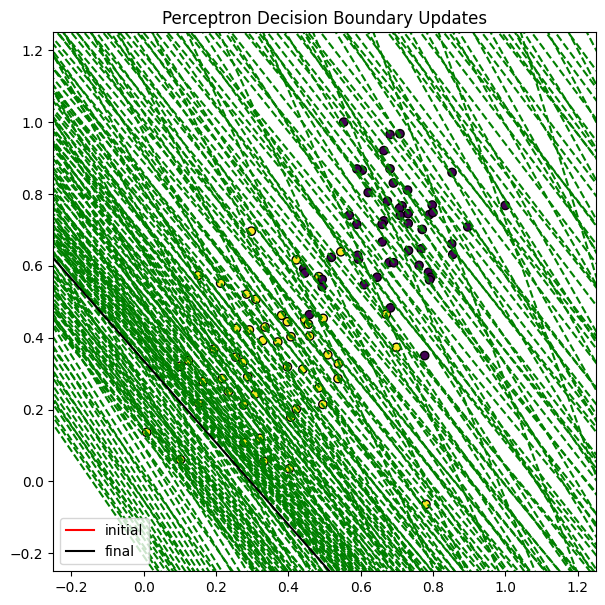

In [99]:
initial_w, initial_b, lines, error_list = perceptron_gradient(X, y, learning_rate=0.1, max_epochs=3)
plot_perceptron_training(X, y, initial_w, initial_b, lines)

In this gradient descent approach model with a learning rate of 0.1 is a bad approach as it does poorly in the seperation of data points. It is also obvious that there is a lot of noise representing the overshooting or overstepping from the big distances/jumps in the green lines. 

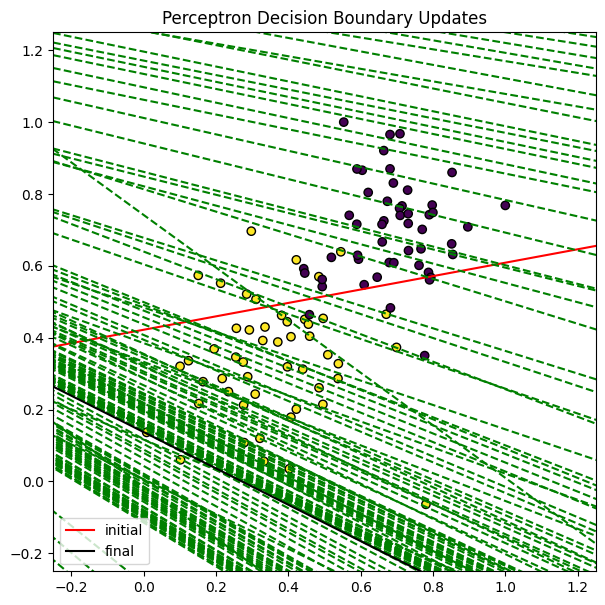

In [101]:
initial_w, initial_b, lines, error_list = perceptron_gradient(X, y, learning_rate=1.0, max_epochs=3)
plot_perceptron_training(X, y, initial_w, initial_b, lines)

This model with a learning rate of 1.0 resulted in the worst performance. There are is a lot of distances between the lines, signifiying the high learning rate.

## Error plot

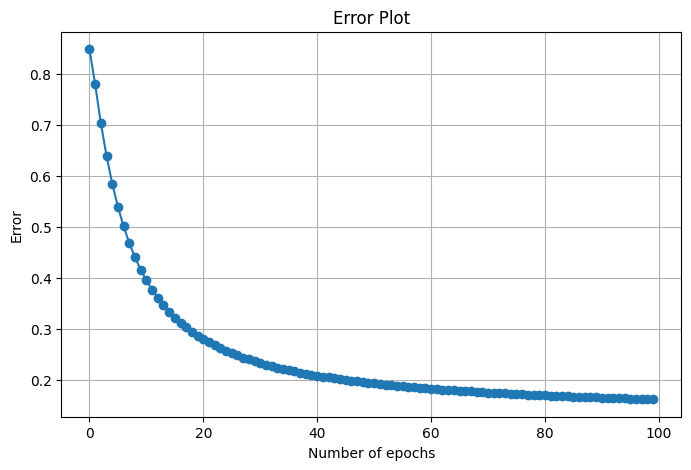

In [60]:
initial_w, initial_b, lines, error_list = perceptron_gradient(X, y, learning_rate=0.01, max_epochs=100)
plot_error_curve(error_list)

In this error rate plot, we can see that the model with a low learning rate shows a high error rate initially, but slowly and smoothly decreses to a very low error rate. This comes back to the main benefit of having a low learning rate. 

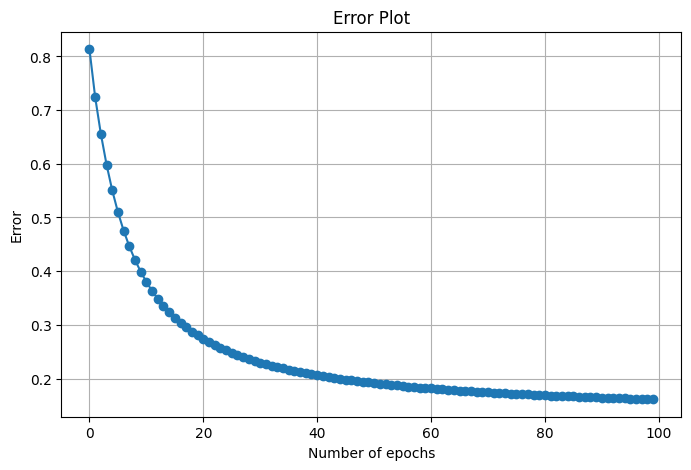

In [103]:
initial_w, initial_b, lines, error_list = perceptron_gradient(X, y, learning_rate=0.1, max_epochs=100)
plot_error_curve(error_list)

Suprisingly, we can see the same type of trend from the previous graph in this graph where the model has a learning rate of 0.1. This has different results compared to the simple heuristic perceptron method due to the gradient descent utilization in this version of the perceptron. 

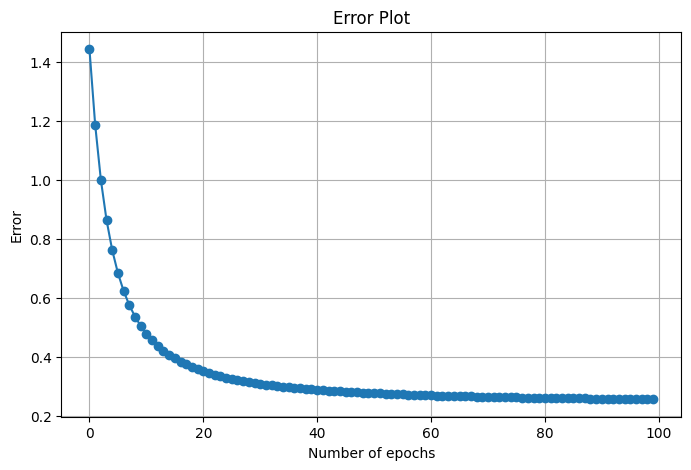

In [104]:
initial_w, initial_b, lines, error_list = perceptron_gradient(X, y, learning_rate=1.0, max_epochs=100)
plot_error_curve(error_list)

Again suprisingly even with a high learning rate, this version of the perceptron outperforms the simple version the higher the epochs there are, even with a high learning rate.